# Preparación de datos - G6

In [2]:
# Liberias
import pandas as pd
import numpy as np
from unidecode import unidecode
from datetime import date
import rasterio
pd.set_option('display.max_columns', None)

## 1. Base de datos principal

- Casos confirmados de Dengue y Dengue grave mensual 2007 a 2024 agregado por municipio de residencia, obtenida del SISPRO del ministerio de salud.
- Codigo divipola y coordenadas obtenidas de datos del DANE
https://www.datos.gov.co/Mapas-Nacionales/DIVIPOLA-C-digos-municipios-geolocalizados/vafm-j2df/about_data
- Datos climaticos mesnuales de temperatura y precipitación obtenidos de archivos historicos de WorldClim
https://www.worldclim.org/data/monthlywth.html


In [29]:

#* Cargar datos de dengue
df = pd.read_csv('data/BaseDengue.csv', sep='|')

#* Remover numero y '-' en columnas Pais, Departamento y Municipio, y conversión a minusculas
cls = ['País', 'Departamento', 'Municipio']
#* Eliminar municipios sin informacion
df = df[~df['Municipio'].str.contains('Sin Informacion')]
for c in cls:
    df[c] = df[c].apply(lambda x: unidecode(x.split('-')[-1].strip().lower()))
df.rename(columns={'Año Epidemiologico': 'Year'}, inplace=True)
df.columns = [unidecode(c) for c in df.columns]

#* Eliminar pais no definido
df = df[df['Pais'] != 'no definido']

#* Reordenar columnas
df = df.melt(
    id_vars=['Pais', 'Departamento', 'Municipio', 'Year'], # Columnas que se mantienen fijas
    var_name='Mes',              # Nombre para la nueva columna con los meses
    value_name='CasosConfirmados' # Nombre para la columna con los valores
)

#* leer archivo divipola
divipola = pd.read_excel('data/Listados_DIVIPOLA.xlsx', sheet_name='Municipios', skiprows=10, skipfooter=10)
divipola
divipola.columns = ['CodigoDepartamento', 'Departamento', 'CodigoMunicipio',
                    'Municipio',
                    'TipoMunicipio', 'Longitud', 'Latitud', 'Nota']

divipola.drop(columns=['Nota', 'CodigoDepartamento'], inplace=True)


#* decode Departamento, Municipio y TipoMunicipio
divipola['Departamento'] = divipola['Departamento'].apply(lambda x: unidecode(x.strip().lower()))
divipola['Municipio'] = divipola['Municipio'].apply(lambda x: unidecode(x.strip().lower()))
divipola['TipoMunicipio'] = divipola['TipoMunicipio'].apply(lambda x: unidecode(x.strip().lower()))

#* Corrección y estandarización de nombres de municipios en df para que coincidan con divipola
renamer = {
    'putumayo': {'leguizamo': 'puerto leguizamo'},
    'cauca': {'sotara': 'sotara paispamba',
              'piendamo': 'piendamo - tunia',
              'lopez': 'lopez de micay'},
    'magdalena': {'cerro san antonio': 'cerro de san antonio',
                  'chibolo': 'chivolo'},
    'antioquia': {'santafe de antioquia': 'santa fe de antioquia',
                #   'san pedro': 'san pedro de uraba',
                  'san vicente': 'san vicente ferrer',
                  'don matias': 'donmatias'},
    'cordoba': {'san andres sotavento': 'san andres de sotavento',
                'purisima': 'purisima de la concepcion'},
    'guainia': {
                'mapiripana': 'mapiripan',
                'barranco minas': 'barrancominas'},
    'valle del cauca': {'cali': 'santiago de cali'},
    'cundinamarca': {'san juan de rio seco': 'san juan de rioseco'},
    'bolivar': {'cartagena': 'cartagena de indias',
                'mompos': 'santa cruz de mompox'},
    # 'sucre': {'tolu viejo': 'santiago de tolu'},
    'narino': {'cuaspud': 'cuaspud carlosama'},
    'tolima': {'mariquita': 'san sebastian de mariquita'},
    'amazonas': {'parana': 'miriti - parana'},
    'norte de santander': {'cucuta': 'san jose de cucuta'},
    'cesar': {'manaure': 'manaure balcon del cesar'},
    'vaupes': {'papunaua': 'papunahua'},
    'choco': {'belen de bajira': 'nuevo belen de bajira'}}

#* rename in df using renamer
for dept, munis in renamer.items():
    for muni, new_muni in munis.items():
        df.loc[(df['Departamento'] == dept) & (df['Municipio'] == muni), 'Municipio'] = new_muni

#* check Departamento and Municipio combinations present in df but not in divipola
df_combinations = set(zip(df['Departamento'], df['Municipio']))
divipola_combinations = set(zip(divipola['Departamento'], divipola['Municipio']))
missing_combinations = df_combinations - divipola_combinations
missing_combinations

#* delete in df where Departamento and Municipio are equal
df = df[~df.apply(lambda x: (x['Departamento'], x['Municipio']) in missing_combinations, axis=1)]

#* merge df and divipola on Departamento and Municipio
df = df.merge(divipola, on=['Departamento', 'Municipio'], how='left', )

#* reorder columns, drop pais and save to csv
df.drop(columns=['Pais'], inplace=True)
df.drop_duplicates(inplace=True)
df = df[['CodigoMunicipio','Departamento', 'Municipio','TipoMunicipio', 'Longitud', 'Latitud', 'Year', 'Mes', 'CasosConfirmados']]

#* Agregar datos climaticos y de elevacion
df['key'] = df['Departamento'] + '_' + df['Municipio']

#* unique combinations for Longitud and Latitud
locs = df[['key','Longitud', 'Latitud']].drop_duplicates(ignore_index=True)

In [30]:

#* obtener elevacion usando rasterio
files = {'Elevacion':r'data\worldclim\wc2.1_2.5m_elev\wc2.1_2.5m_elev.tif',
         } #! Datos elevacion
         
resultados = {}
for var,file in files.items():
    resultados[var] = []
    with rasterio.open(file) as src:
        # src.sample expects an iterable of (x, y) coordinates
        # For geospatial data, x is Longitude and y is Latitude
        for index, row in locs.iterrows():
            coordinates = [(row['Longitud'], row['Latitud'])]
            sample_gen = src.sample(coordinates)
            
            for result in sample_gen:
            # result is an array of values for each band. 
            # WorldClim files typically have 1 band per file.
                resultados[var].append(result[0])


In [31]:
locs['Elevacion'] = resultados['Elevacion']
#* agregar elevacion a df usando key
df = df.merge(locs[['key', 'Elevacion']], on='key', how='left')


In [32]:

#* Obetner temperatura y precipitacion mensual
files = {'tmin':[r'data\worldclim\wc2.1_cruts4.09_2.5m_tmin_2000-2009',
                           r'data\worldclim\wc2.1_cruts4.09_2.5m_tmin_2010-2019',
                           r'data\worldclim\wc2.1_cruts4.09_2.5m_tmin_2020-2024'],
         'tmax':[r'data\worldclim\wc2.1_cruts4.09_2.5m_tmax_2000-2009',
                           r'data\worldclim\wc2.1_cruts4.09_2.5m_tmax_2010-2019',
                           r'data\worldclim\wc2.1_cruts4.09_2.5m_tmax_2020-2024'],
         'prec':[r'data\worldclim\wc2.1_cruts4.09_2.5m_prec_2000-2009',
                         r'data\worldclim\wc2.1_cruts4.09_2.5m_prec_2010-2019',
                         r'data\worldclim\wc2.1_cruts4.09_2.5m_prec_2020-2024']
        }


locs = df[['key','Longitud', 'Latitud', 'Year', 'Mes']].drop_duplicates(ignore_index=True)
# locs

In [33]:
parse_month = {'Enero': '01', 'Febrero': '02', 'Marzo': '03', 'Abril': '04', 'Mayo': '05', 'Junio': '06',
               'Julio': '07', 'Agosto': '08', 'Septiembre': '09', 'Octubre': '10', 'Noviembre': '11', 'Diciembre': '12'}

locs['Mes'] = locs['Mes'].apply(lambda x: parse_month[x])
df['Mes'] = df['Mes'].apply(lambda x: parse_month[x])
locs.sort_values(['Year', 'Mes'], inplace=True)
locs.reset_index(drop=True, inplace=True)
#* por cada combinacion año mes, abrir archivo y obtener datos climaticos por coordenada
y_m_combinations = locs[['Year', 'Mes']].drop_duplicates()
results = []
for var, folders in files.items():
    for y,m in y_m_combinations.itertuples(index=False):
        #* determinar carpeta a abrir segun año
        if y <= 2009:
            folder = folders[0]
        elif y <= 2019:
            folder = folders[1]
        else:
            folder = folders[2]
        
        file = f"{folder + '\\' + '_'.join(folder.split('\\')[-1].split('_')[:-1]) + f'_{y}-{m}.tif'}"
        with rasterio.open(file) as src:
            for index, row in locs[(locs['Year'] == y) & (locs['Mes'] == m)].iterrows():
                coordinates = [(row['Longitud'], row['Latitud'])]
                sample_gen = src.sample(coordinates)
                
                for result in sample_gen:
                    results.append((row['Longitud'], row['Latitud'], y, m, var, result[0]))
        

In [34]:
results_df = pd.DataFrame(results, columns=['Longitud', 'Latitud', 'Year', 'Mes', 'Variable', 'Valor'])
#* melt results_df para tener columnas separadas para cada variable
results_df = results_df.pivot_table(index=['Longitud', 'Latitud', 'Year', 'Mes'], columns='Variable', values='Valor').reset_index()
#* merge con df para agregar variables climaticas
df = df.merge(results_df, on=['Longitud', 'Latitud', 'Year', 'Mes'], how='left')

In [35]:

#* Rename cols prec, tmax y tmin a Precipitacion, TempMax y TempMin
df.rename(columns={'prec': 'Precipitacion', 'tmax': 'TempMax', 'tmin': 'TempMin'}, inplace=True)
#* drop nan precipitacion rows
df = df[~df['Precipitacion'].isna()]
#* drop key column
df.drop(columns=['key'], inplace=True)
#* save to csv
df.to_csv('data/dengue_data_v2.csv', index=False, sep='|')

In [37]:
df

,CodigoMunicipio,Departamento,Municipio,TipoMunicipio,Longitud,Latitud,Year,Mes,CasosConfirmados,Elevacion,Precipitacion,TempMax,TempMin
0,5001,antioquia,medellin,municipio,-75.581775,6.246631,2007,01,1.0,1609,66.900002,25.0,17.0
1,5001,antioquia,medellin,municipio,-75.581775,6.246631,2008,01,128.0,1609,88.599998,26.0,15.0
2,5001,antioquia,medellin,municipio,-75.581775,6.246631,2009,01,30.0,1609,137.500000,26.0,15.0
3,5001,antioquia,medellin,municipio,-75.581775,6.246631,2010,01,130.0,1609,18.400000,29.0,16.0
4,5001,antioquia,medellin,municipio,-75.581775,6.246631,2011,01,126.0,1609,110.900002,27.0,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
178327,99773,vichada,cumaribo,municipio,-69.795533,4.446352,2020,12,5.0,134,77.699997,33.0,23.0
178328,99773,vichada,cumaribo,municipio,-69.795533,4.446352,2021,12,1.0,134,75.099998,33.0,23.0
178329,99773,vichada,cumaribo,municipio,-69.795533,4.446352,2022,12,7.0,134,77.000000,32.0,22.0
178330,99773,vichada,cumaribo,municipio,-69.795533,4.446352,2023,12,8.0,134,79.599998,33.0,23.0


## 2. Análisis exploratorio de datos

In [2]:
df = pd.read_csv('data/dengue_data_v2.csv', sep='|')
cols_t_str = ['CodigoMunicipio', 'Year', 'Mes']
for col in cols_t_str:
    df[col] = df[col].astype(str)
df.head()


,CodigoMunicipio,Departamento,Municipio,TipoMunicipio,Longitud,Latitud,Year,Mes,CasosConfirmados,Elevacion,Precipitacion,TempMax,TempMin
0,5001,antioquia,medellin,municipio,-75.581775,6.246631,2007,1,1.0,1609,66.9,25.0,17.0
1,5001,antioquia,medellin,municipio,-75.581775,6.246631,2008,1,128.0,1609,88.6,26.0,15.0
2,5001,antioquia,medellin,municipio,-75.581775,6.246631,2009,1,30.0,1609,137.5,26.0,15.0
3,5001,antioquia,medellin,municipio,-75.581775,6.246631,2010,1,130.0,1609,18.4,29.0,16.0
4,5001,antioquia,medellin,municipio,-75.581775,6.246631,2011,1,126.0,1609,110.9,27.0,15.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 177936 entries, 0 to 177935
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   CodigoMunicipio   177936 non-null  str    
 1   Departamento      177936 non-null  str    
 2   Municipio         177936 non-null  str    
 3   TipoMunicipio     177936 non-null  str    
 4   Longitud          177936 non-null  float64
 5   Latitud           177936 non-null  float64
 6   Year              177936 non-null  str    
 7   Mes               177936 non-null  str    
 8   CasosConfirmados  177936 non-null  float64
 9   Elevacion         177936 non-null  int64  
 10  Precipitacion     177936 non-null  float64
 11  TempMax           177936 non-null  float64
 12  TempMin           177936 non-null  float64
dtypes: float64(6), int64(1), str(6)
memory usage: 23.9 MB


In [4]:
df[[ 'CasosConfirmados', 'Elevacion', 'Precipitacion', 'TempMax', 'TempMin']].describe()

,CasosConfirmados,Elevacion,Precipitacion,TempMax,TempMin
count,177936.000000,177936.000000,177936.00000,177936.000000,177936.000000
mean,9.123662,946.347046,178.37009,28.425979,18.657056
std,60.614911,842.253971,134.46565,4.765420,4.651171
min,0.000000,3.000000,0.10000,9.000000,2.000000
25%,0.000000,130.000000,82.30000,25.000000,15.000000
50%,1.000000,886.000000,153.70000,29.000000,19.000000
75%,4.000000,1583.000000,243.50000,32.000000,23.000000
max,5148.000000,3690.000000,1382.40000,38.000000,28.000000


In [5]:
df[[ 'CasosConfirmados', 'Elevacion', 'Precipitacion', 'TempMax', 'TempMin']].corr()

,CasosConfirmados,Elevacion,Precipitacion,TempMax,TempMin
CasosConfirmados,1.000000,-0.040230,-0.009136,0.057229,0.048863
Elevacion,-0.040230,1.000000,-0.151916,-0.949265,-0.977635
Precipitacion,-0.009136,-0.151916,1.000000,0.003500,0.135603
TempMax,0.057229,-0.949265,0.003500,1.000000,0.944542
TempMin,0.048863,-0.977635,0.135603,0.944542,1.000000


In [13]:
int(df[(df['Year']=='2024') & (df['Mes']==5)]['CasosConfirmados'].sum())

37973

In [7]:
# departamentos con mas casos confirmados y porcentaje del total
total_casos = int(df['CasosConfirmados'].sum())
df_departamentos = df[['Departamento', 'CasosConfirmados']].groupby('Departamento').sum().reset_index(drop=False)
df_departamentos['CasosConfirmados'] = df_departamentos['CasosConfirmados'].astype(int)
df_departamentos['Porcentaje'] = (df_departamentos['CasosConfirmados'] / total_casos) * 100
df_departamentos.sort_values('CasosConfirmados', ascending=False).head(25).reset_index(drop=True)

,Departamento,CasosConfirmados,Porcentaje
0,valle del cauca,288044,17.742949
1,santander,165694,10.206427
2,tolima,126530,7.794001
3,antioquia,123114,7.583582
4,meta,98053,6.039874
5,huila,92133,5.675213
6,norte de santander,83329,5.132904
7,atlantico,79238,4.880906
8,bolivar,64775,3.990014
9,cesar,51581,3.177289


In [42]:
# valumne de datos por departamento y municipio
# max data municipio
min_y = int(df['Year'].min())
max_y = int(df['Year'].max())
months = 12
max_dt_muni = (max_y - min_y + 1 )* months

# departamentos con mas casos confirmados 
df.groupby()


# departamentos de interes boyaca, cundinamarca


TypeError: You have to supply one of 'by' and 'level'

In [8]:
#libs
## Librerías de visualización 
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import seaborn as sns

In [9]:
# funciones para analisis exploratorio y visualizacion de datos

#* Análisis de correlación
def plot_correlation_map( df ):
    corr = df.corr()
    _ , ax = plt.subplots( figsize =( 12 , 10 ) )
    cmap = sns.diverging_palette( 220 , 10 , as_cmap = True )
    _ = sns.heatmap(
        corr, 
        cmap = cmap,
        square=True, 
        cbar_kws={ 'shrink' : .9 }, 
        ax=ax, 
        annot = True, 
        annot_kws = { 'fontsize' : 12 }
    )

def frecuencia_mensual_con_umbral(df, umbral=5000):
    #* frecuencia por meses y años en cundinamarca con años separados en diferentes subplots
    df_agrupado = df.groupby(['Year', 'Mes'])['CasosConfirmados'].sum().reset_index()
    df_agrupado = df_agrupado.sort_values(by=['Year', 'Mes'])

    # 2. Configuración del estilo
    sns.set_theme(style="whitegrid")

    # 3. Creación de la cuadrícula
    g = sns.FacetGrid(df_agrupado, col="Year", col_wrap=4, height=3, aspect=1.5, sharex=False, sharey=False)

    # 4. Gráfico principal (Línea de casos)
    g.map(sns.lineplot, "Mes", "CasosConfirmados", marker="o")

    # umbral
    g.refline(y=umbral, color="red", linestyle="--", linewidth=1.5, label="Umbral 5000")

    # 5. Ajustes finales
    g.set_axis_labels("Mes", "Total Casos")
    g.set_titles(col_template="Año {col_name}")
    g.fig.suptitle("Comportamiento Mensual vs Umbral de Referencia", y=1.02)

    g.add_legend()

    plt.show()

def frecuencia_mensual_con_umbral_v2(df, umbral=5000, anos_por_subplot=1):
    """
    Genera gráficos de línea para casos confirmados.
    
    Args:
        df: DataFrame con columnas 'Year', 'Mes', 'CasosConfirmados'.
        umbral: Valor para la línea horizontal de referencia.
        anos_por_subplot: Cantidad de años continuos a mostrar en cada gráfica (ej. 2 para pares de años).
    """
    
    # 1. Agrupación inicial
    df_agrupado = df.groupby(['Year', 'Mes'])['CasosConfirmados'].sum().reset_index()
    
    # 2. Crear columna 'Fecha' para tener un Eje X continuo
    # Es vital convertir a datetime para que al graficar 2 o 3 años seguidos, 
    # la línea continúe cronológicamente y no se superpongan los meses.
    df_agrupado['Fecha'] = pd.to_datetime(
        df_agrupado['Year'].astype(str) + '-' + df_agrupado['Mes'].astype(str) + '-01'
    )
    df_agrupado = df_agrupado.sort_values('Fecha')

    # 3. Definir los bloques de años (Periodos)
    min_year = df_agrupado['Year'].min()
    
    # Calculamos un índice de bloque: (AñoActual - AñoMinimo) // N
    df_agrupado['Bloque_Indice'] = (df_agrupado['Year'] - min_year) // anos_por_subplot
    
    # Generamos etiquetas legibles para los títulos (Ej: "2007-2008")
    def generar_etiqueta(row):
        inicio = min_year + (row['Bloque_Indice'] * anos_por_subplot)
        fin = inicio + anos_por_subplot - 1
        if anos_por_subplot == 1:
            return str(inicio)
        return f"{inicio} - {fin}"

    df_agrupado['Periodo'] = df_agrupado.apply(generar_etiqueta, axis=1)

    # 4. Configuración del estilo
    sns.set_theme(style="whitegrid")

    # 5. Creación de la cuadrícula
    # Usamos 'Periodo' en col, y aumentamos el 'aspect' (ancho) para que quepan mejor las fechas
    g = sns.FacetGrid(df_agrupado, col="Periodo", col_wrap=3, height=3.5, aspect=2, sharex=False, sharey=False)

    # 6. Gráfico principal
    # Usamos 'Fecha' en el eje X en lugar de 'Mes'
    g.map(sns.lineplot, "Fecha", "CasosConfirmados", marker="o")

    # Umbral
    g.refline(y=umbral, color="red", linestyle="--", linewidth=1.5, label=f"Umbral {umbral}")

    # 7. Ajustes finales
    g.set_axis_labels("Fecha", "Total Casos")
    g.set_titles(col_template="{col_name}")
    g.fig.suptitle(f"Comportamiento de Casos ({anos_por_subplot} años por gráfica)", y=1.02)

    # Rotación de fechas en el eje X para evitar solapamiento
    for ax in g.axes.flat:
        for label in ax.get_xticklabels():
            label.set_rotation(45)
            label.set_horizontalalignment('right')

    g.add_legend()
    plt.show()



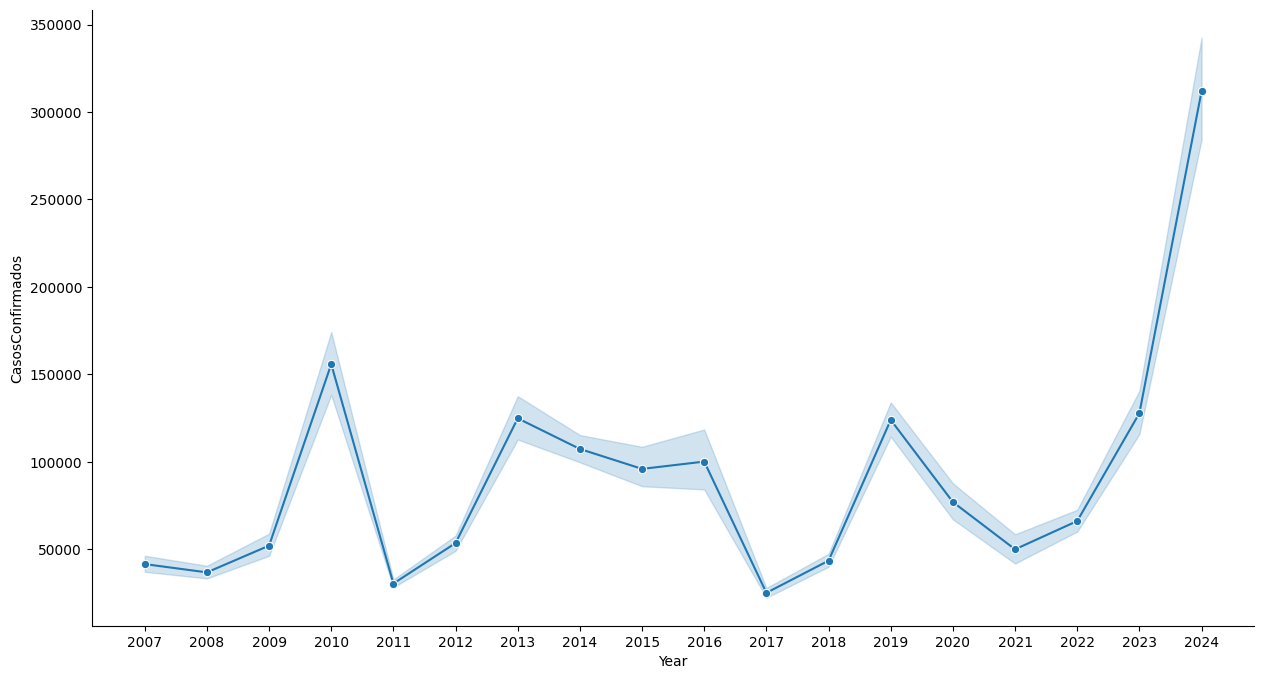

In [10]:
#* Casos confirmados por año
plt.figure(figsize=(15,8))
sns.lineplot(data=df, x='Year', y='CasosConfirmados', estimator='sum', marker='o')
# remove borders right and top
sns.despine()
# plt.title('Casos confirmados de dengue por año en Colombia')

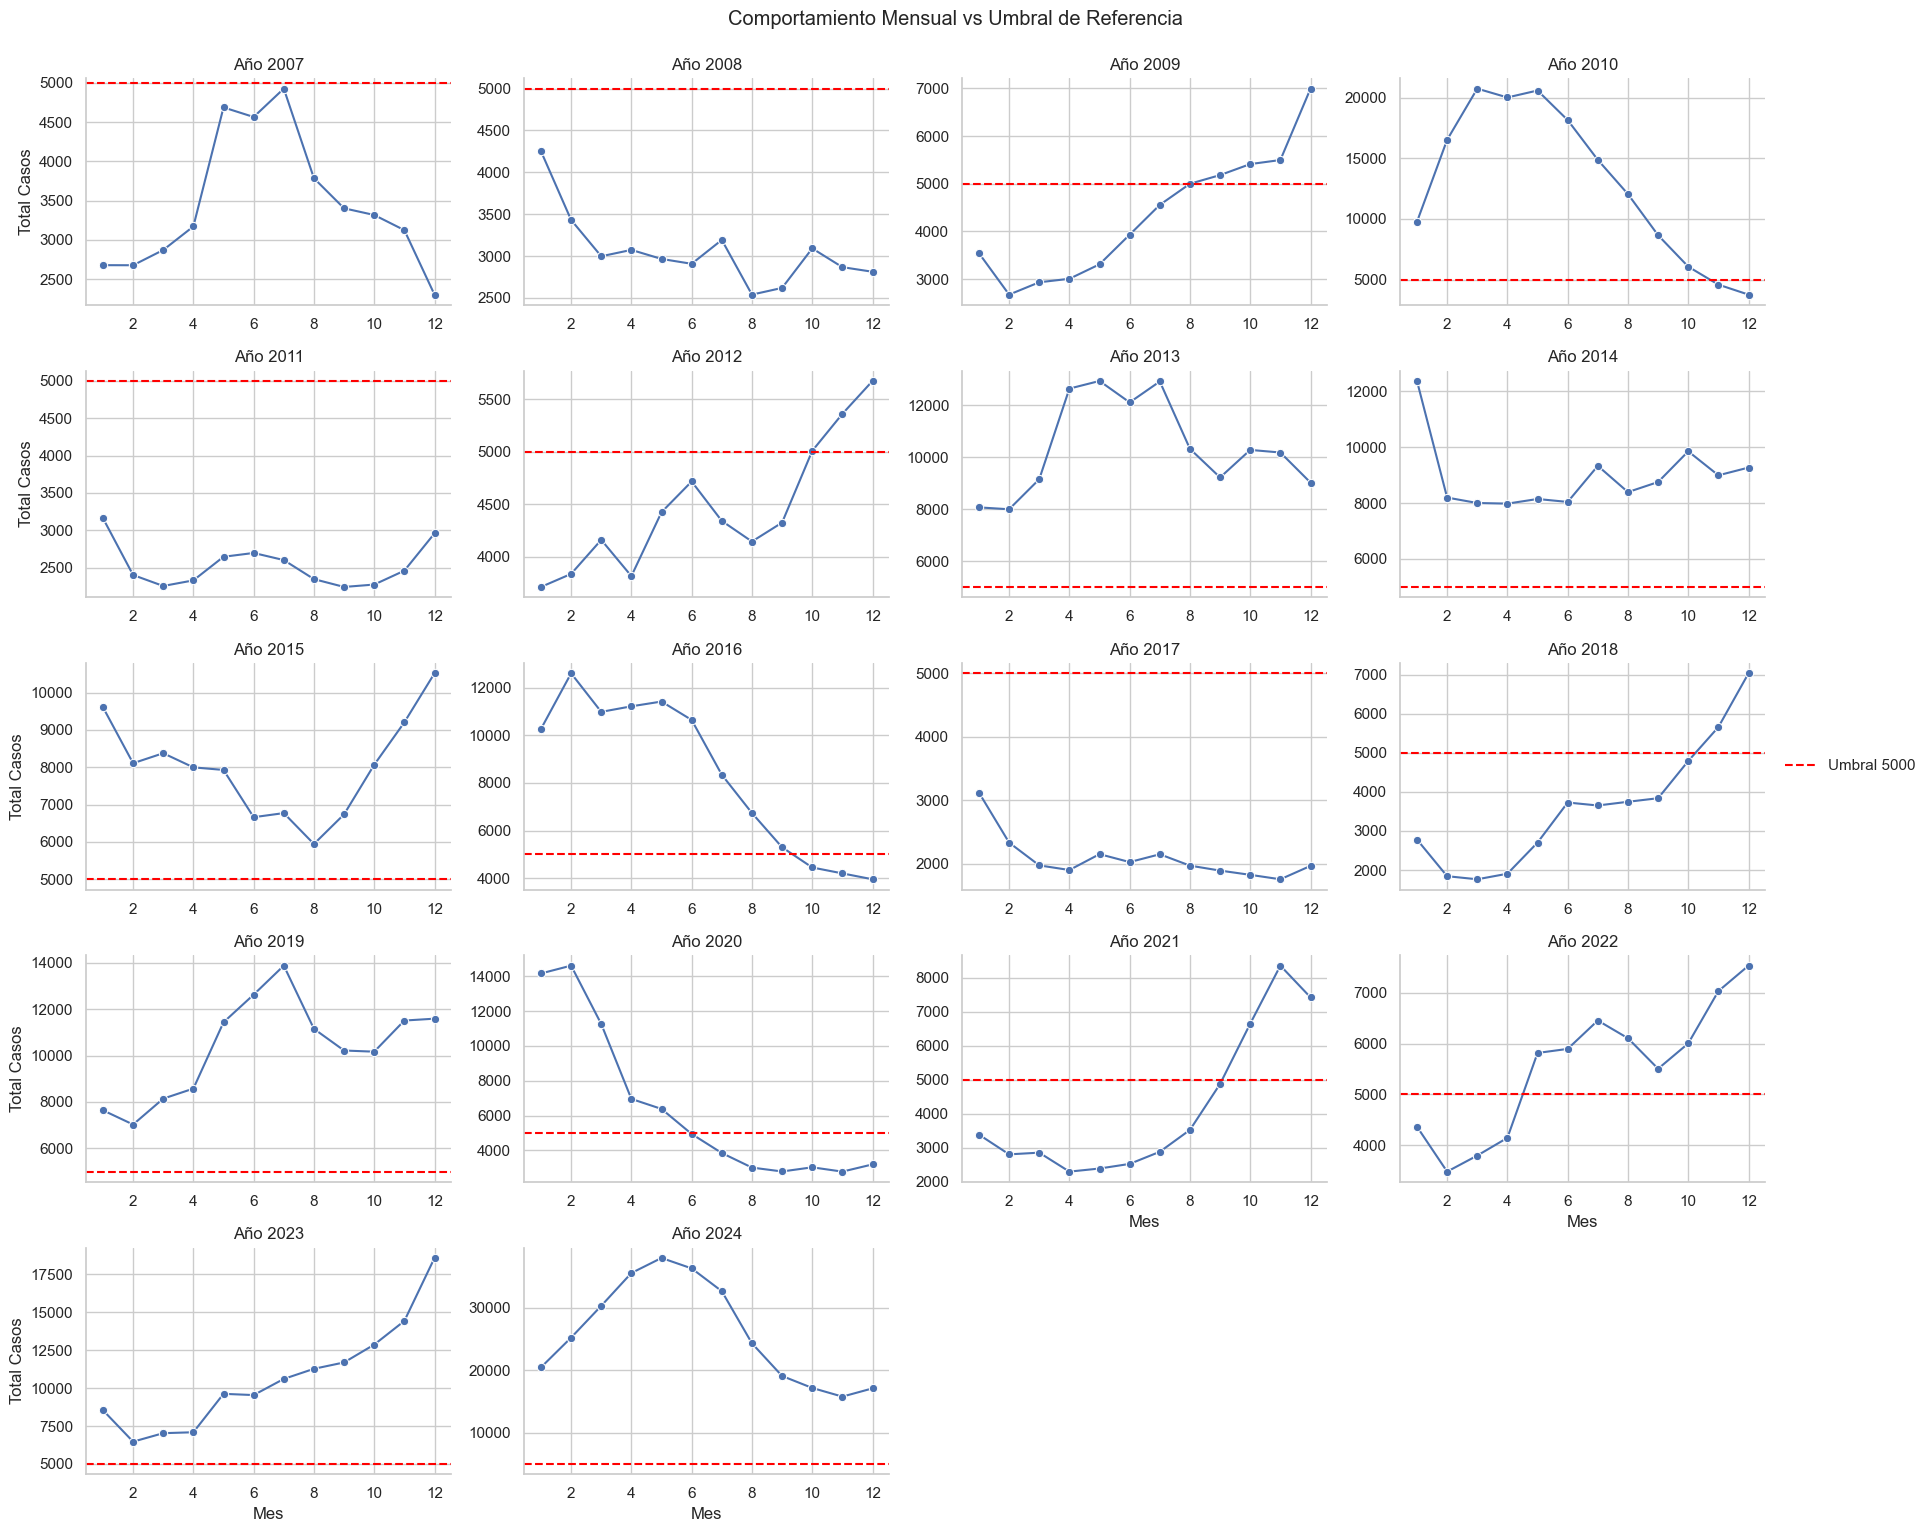

In [ ]:
df['Mes'] = df['Mes'].apply(lambda x: int(x))
frecuencia_mensual_con_umbral(df)

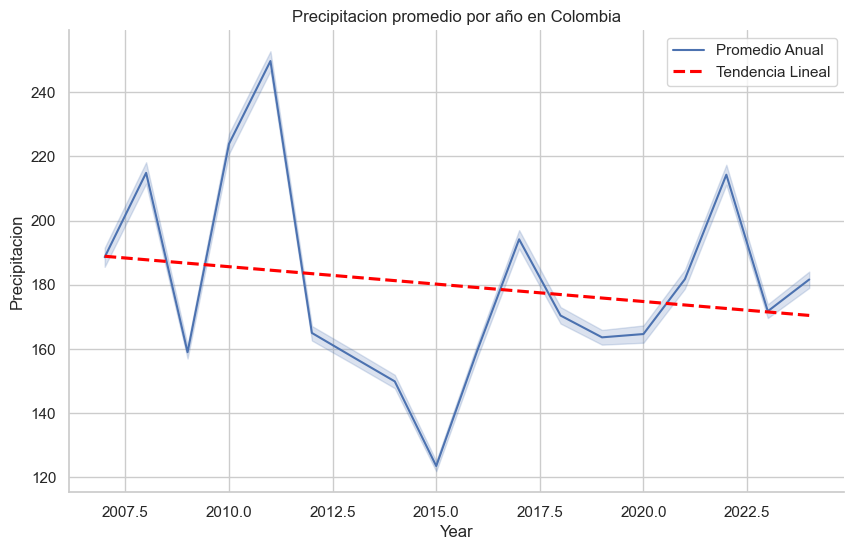

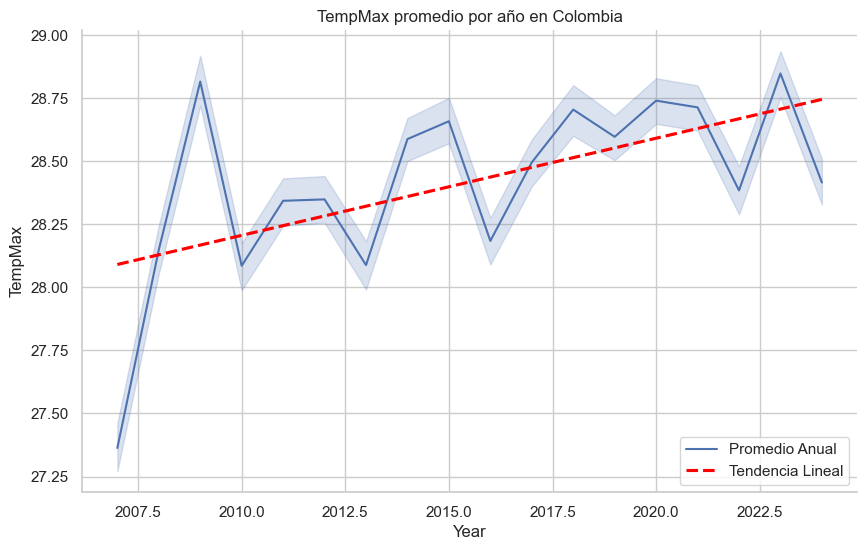

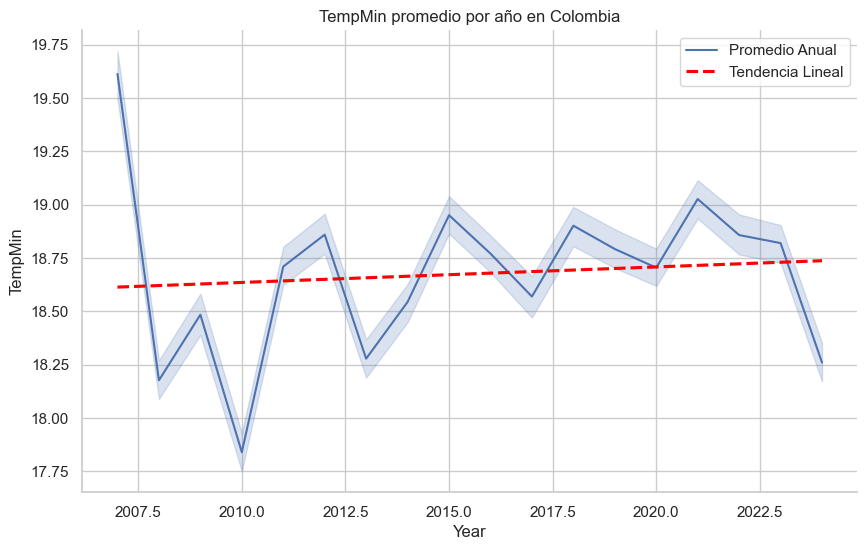

In [17]:
#* temperaturas y precipitacion promedio por año
cols = ['Precipitacion','TempMax','TempMin']
df['Year'] = df['Year'].astype(int)
for col in cols:
    plt.figure(figsize=(10, 6))
    
    # 1. Tu gráfica original (Línea de promedios anuales)
    sns.lineplot(data=df, x='Year', y=col, estimator='mean', label='Promedio Anual')
    
    # 2. Preparar datos para la tendencia (Agrupamos por año para obtener el promedio)
    # Esto es necesario porque lineplot agrega internamente, pero para calcular la tendencia
    # necesitamos los puntos exactos (x, y) de esos promedios.
    df_trend = df.groupby('Year')[col].mean().reset_index()
    
    # 3. Graficar la línea de tendencia usando regplot
    # scatter=False evita que pinte los puntos de nuevo, solo queremos la línea
    # ci=None quita la sombra del intervalo de confianza (opcional, puedes dejarlo si prefieres)
    sns.regplot(data=df_trend, x='Year', y=col, scatter=False, color='red', line_kws={'linestyle':'--'}, label='Tendencia Lineal', ci=None)
    
    plt.title(f'{col} promedio por año en Colombia')
    plt.legend()
    sns.despine()
    plt.show()
    



In [18]:
df

,CodigoMunicipio,Departamento,Municipio,TipoMunicipio,Longitud,Latitud,Year,Mes,CasosConfirmados,Elevacion,Precipitacion,TempMax,TempMin
0,5001,antioquia,medellin,municipio,-75.581775,6.246631,2007,1,1.0,1609,66.9,25.0,17.0
1,5001,antioquia,medellin,municipio,-75.581775,6.246631,2008,1,128.0,1609,88.6,26.0,15.0
2,5001,antioquia,medellin,municipio,-75.581775,6.246631,2009,1,30.0,1609,137.5,26.0,15.0
3,5001,antioquia,medellin,municipio,-75.581775,6.246631,2010,1,130.0,1609,18.4,29.0,16.0
4,5001,antioquia,medellin,municipio,-75.581775,6.246631,2011,1,126.0,1609,110.9,27.0,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
177931,99773,vichada,cumaribo,municipio,-69.795533,4.446352,2020,12,5.0,134,77.7,33.0,23.0
177932,99773,vichada,cumaribo,municipio,-69.795533,4.446352,2021,12,1.0,134,75.1,33.0,23.0
177933,99773,vichada,cumaribo,municipio,-69.795533,4.446352,2022,12,7.0,134,77.0,32.0,22.0
177934,99773,vichada,cumaribo,municipio,-69.795533,4.446352,2023,12,8.0,134,79.6,33.0,23.0


In [34]:
# crear df con rezago de temperaturas y precipitacion
df_lag = df.copy()
df_lag.drop(columns=['CodigoMunicipio'], inplace=True)
df_lag.sort_values(['Departamento', 'Municipio', 'Year', 'Mes'], inplace=True)

df_lag.reset_index(drop=True, inplace=True)
df_lag

,Departamento,Municipio,TipoMunicipio,Longitud,Latitud,Year,Mes,CasosConfirmados,Elevacion,Precipitacion,TempMax,TempMin
0,amazonas,el encanto,area no municipalizada,-73.207114,-1.748060,2019,1,0.0,158,199.7,31.0,23.0
1,amazonas,el encanto,area no municipalizada,-73.207114,-1.748060,2019,2,0.0,158,146.4,31.0,23.0
2,amazonas,el encanto,area no municipalizada,-73.207114,-1.748060,2019,3,0.0,158,328.7,31.0,23.0
3,amazonas,el encanto,area no municipalizada,-73.207114,-1.748060,2019,4,0.0,158,389.0,31.0,22.0
4,amazonas,el encanto,area no municipalizada,-73.207114,-1.748060,2019,5,0.0,158,253.1,30.0,23.0
...,...,...,...,...,...,...,...,...,...,...,...,...
177931,vichada,santa rosalia,municipio,-70.859499,5.136393,2024,8,0.0,116,255.6,31.0,22.0
177932,vichada,santa rosalia,municipio,-70.859499,5.136393,2024,9,3.0,116,211.5,32.0,23.0
177933,vichada,santa rosalia,municipio,-70.859499,5.136393,2024,10,2.0,116,238.2,32.0,23.0
177934,vichada,santa rosalia,municipio,-70.859499,5.136393,2024,11,0.0,116,149.6,32.0,23.0


In [ ]:
df_lag['Precipitacion_Lag1'] = df_lag.groupby(['Departamento', 'Municipio'])['Precipitacion'].shift(1)
df_lag['Precipitacion_Lag2'] = df_lag.groupby(['Departamento', 'Municipio'])['Precipitacion'].shift(2)
df_lag['Precipitacion_Lag3'] = df_lag.groupby(['Departamento', 'Municipio'])['Precipitacion'].shift(3)
df_lag['TempMax_Lag1'] = df_lag.groupby(['Departamento', 'Municipio'])['TempMax'].shift(1)
df_lag['TempMax_Lag2'] = df_lag.groupby(['Departamento', 'Municipio'])['TempMax'].shift(2)
df_lag['TempMax_Lag3'] = df_lag.groupby(['Departamento', 'Municipio'])['TempMax'].shift(3)
df_lag['TempMin_Lag1'] = df_lag.groupby(['Departamento', 'Municipio'])['TempMin'].shift(1)
df_lag['TempMin_Lag2'] = df_lag.groupby(['Departamento', 'Municipio'])['TempMin'].shift(2)
df_lag['TempMin_Lag3'] = df_lag.groupby(['Departamento', 'Municipio'])['TempMin'].shift(3)



SyntaxError: invalid syntax (67378595.py, line 13)

In [1]:
df_lag

NameError: name 'df_lag' is not defined

In [39]:
df_lag.dropna(inplace=True)
df_lag.reset_index(drop=True, inplace=True)
df_lag.head()

,Departamento,Municipio,TipoMunicipio,Longitud,Latitud,Year,Mes,CasosConfirmados,Elevacion,Precipitacion,TempMax,TempMin,Precipitacion_Lag1,Precipitacion_Lag2,Precipitacion_Lag3,TempMax_Lag1,TempMax_Lag2,TempMax_Lag3,TempMin_Lag1,TempMin_Lag2,TempMin_Lag3
0,amazonas,el encanto,area no municipalizada,-73.207114,-1.74806,2019,4,0.0,158,389.0,31.0,22.0,328.7,146.4,199.7,31.0,31.0,31.0,23.0,23.0,23.0
1,amazonas,el encanto,area no municipalizada,-73.207114,-1.74806,2019,5,0.0,158,253.1,30.0,23.0,389.0,328.7,146.4,31.0,31.0,31.0,22.0,23.0,23.0
2,amazonas,el encanto,area no municipalizada,-73.207114,-1.74806,2019,6,0.0,158,272.1,30.0,22.0,253.1,389.0,328.7,30.0,31.0,31.0,23.0,22.0,23.0
3,amazonas,el encanto,area no municipalizada,-73.207114,-1.74806,2019,7,0.0,158,237.7,29.0,21.0,272.1,253.1,389.0,30.0,30.0,31.0,22.0,23.0,22.0
4,amazonas,el encanto,area no municipalizada,-73.207114,-1.74806,2019,8,0.0,158,141.5,31.0,21.0,237.7,272.1,253.1,29.0,30.0,30.0,21.0,22.0,23.0


In [54]:
df_lag.to_csv('data/dengue_data_v3.csv', index=False, sep='|')

In [62]:
# df_lag agrupado por mes en un año especifico
df_lag_2 = df_lag[df_lag['Year'] == 2023]
df_lag_2 = df_lag_2.groupby(['Year', 'Mes'])[['CasosConfirmados',
                                   'Precipitacion_Lag1', 'TempMax_Lag1', 'TempMin_Lag1',
                                   'Precipitacion_Lag2', 'TempMax_Lag2', 'TempMin_Lag2',
                                   'Precipitacion_Lag3', 'TempMax_Lag3', 'TempMin_Lag3']].agg({'CasosConfirmados': 'sum',
                                                                                              'Precipitacion_Lag1': 'mean', 'TempMax_Lag1': 'mean', 'TempMin_Lag1': 'mean',
                                                                                              'Precipitacion_Lag2': 'mean', 'TempMax_Lag2': 'mean', 'TempMin_Lag2': 'mean',
                                                                                              'Precipitacion_Lag3': 'mean', 'TempMax_Lag3': 'mean', 'TempMin_Lag3': 'mean'}).reset_index(drop=False)

In [63]:
# normalizar variables no temporales
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_lag_2[['Precipitacion_Lag1', 'TempMax_Lag1', 'TempMin_Lag1']] = scaler.fit_transform(df_lag_2[['Precipitacion_Lag1', 'TempMax_Lag1', 'TempMin_Lag1']])
df_lag_2[['Precipitacion_Lag2', 'TempMax_Lag2', 'TempMin_Lag2']] = scaler.fit_transform(df_lag_2[['Precipitacion_Lag2', 'TempMax_Lag2', 'TempMin_Lag2']])
df_lag_2[['Precipitacion_Lag3', 'TempMax_Lag3', 'TempMin_Lag3']] = scaler.fit_transform(df_lag_2[['Precipitacion_Lag3', 'TempMax_Lag3', 'TempMin_Lag3']])

df_lag_2['CasosConfirmados'] = scaler.fit_transform(df_lag_2[['CasosConfirmados']])

df_lag_2

,Year,Mes,CasosConfirmados,Precipitacion_Lag1,TempMax_Lag1,TempMin_Lag1,Precipitacion_Lag2,TempMax_Lag2,TempMin_Lag2,Precipitacion_Lag3,TempMax_Lag3,TempMin_Lag3
0,2023,1,-0.629670,-1.247979,-1.476658,-1.342066,1.873618,-2.119684,-0.740552,1.548817,-1.068428,-0.137500
1,2023,2,-1.251876,-0.131680,-1.228435,-2.098711,-1.214233,-0.989739,-1.216126,1.815991,-1.901353,-0.702480
2,2023,3,-1.084117,-1.900452,0.381008,-1.209436,-0.291908,-0.796746,-1.958278,-1.202039,-0.831082,-1.179717
3,2023,4,-1.065843,-0.098445,-0.549827,-0.133174,-1.753330,0.454598,-1.086036,-0.300568,-0.648281,-1.924463
4,2023,5,-0.306435,1.236821,-0.990222,0.323422,-0.264448,-0.269127,-0.030390,-1.728946,0.536978,-1.049172
5,2023,6,-0.330999,0.845628,-0.035365,1.545360,0.838797,-0.611535,0.417460,-0.273729,-0.148526,0.010165
6,2023,7,-0.011958,-0.094344,0.092750,0.771321,0.515579,0.130867,1.615992,0.804569,-0.472851,0.459581
7,2023,8,0.188155,0.162875,1.035596,0.899603,-0.261059,0.230477,0.856780,0.488660,0.230344,1.662304
8,2023,9,0.313974,0.290168,1.518028,0.421264,-0.048536,0.963540,0.982604,-0.270417,0.324693,0.900437
9,2023,10,0.666268,-0.824097,1.804285,0.240800,0.056638,1.338632,0.513428,-0.062700,1.019043,1.026701


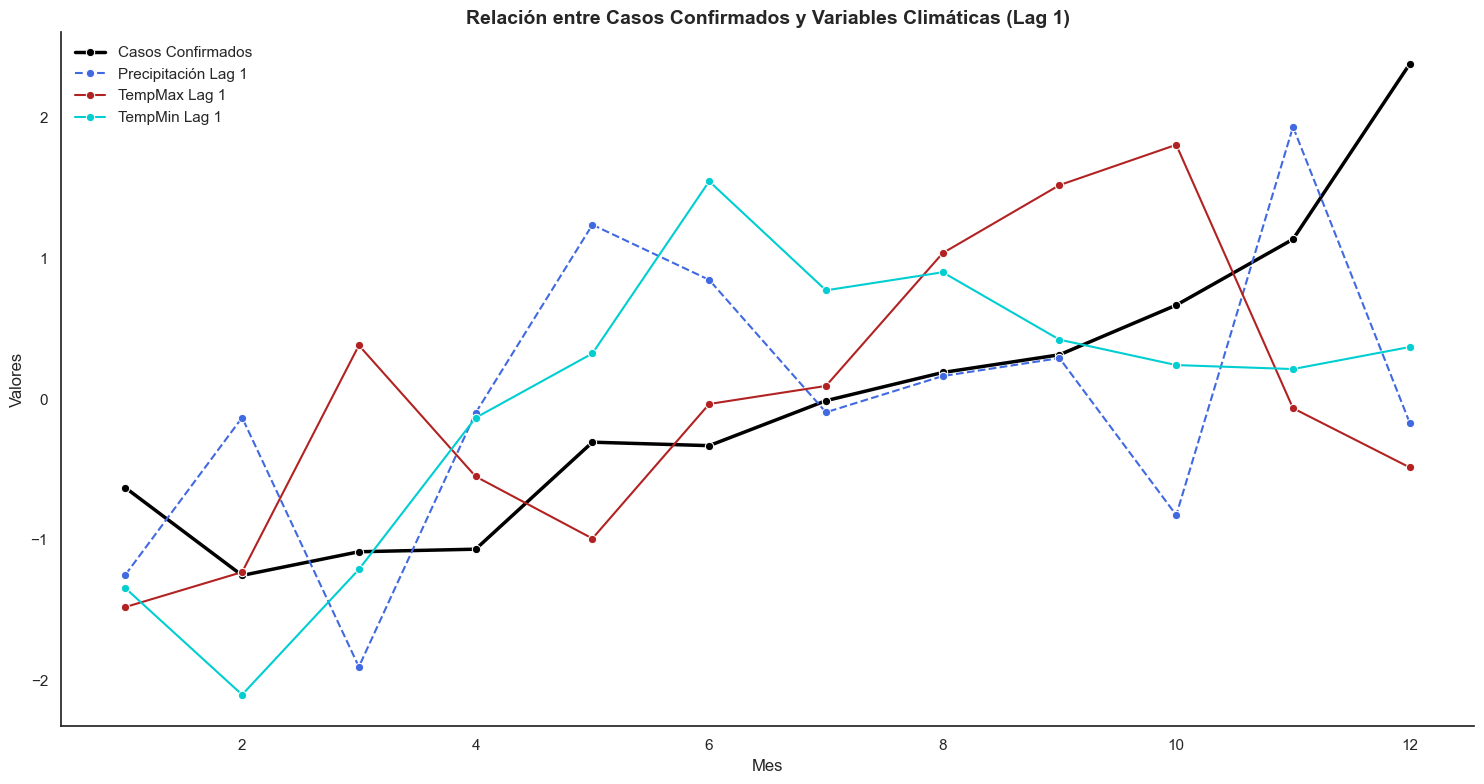

In [64]:
# line graph of CasosConfirmados vs Precipitacion_Lag1, TempMax_Lag1 and TempMin_Lag1
# Set a clean style
sns.set_style("white")

plt.figure(figsize=(15, 8))

# 1. Casos Confirmados: Stronger color and thicker line to make it the focus
sns.lineplot(data=df_lag_2, x='Mes', y='CasosConfirmados', 
             marker='o', label='Casos Confirmados', 
             color='black', linewidth=2.5, errorbar=None)

# 2. Precipitacion: Blue color with a dashed/dotted line style
sns.lineplot(data=df_lag_2, x='Mes', y='Precipitacion_Lag1', 
             marker='o', label='Precipitación Lag 1', 
             color='royalblue', linestyle='--', errorbar=None)

# 3. Temp Max: Warm color (red/orange)
sns.lineplot(data=df_lag_2, x='Mes', y='TempMax_Lag1', 
             marker='o', label='TempMax Lag 1', 
             color='firebrick', errorbar=None)

# 4. Temp Min: Cool color (cyan/light blue)
sns.lineplot(data=df_lag_2, x='Mes', y='TempMin_Lag1', 
             marker='o', label='TempMin Lag 1', 
             color='darkturquoise', errorbar=None)

# Final formatting
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Valores', fontsize=12)
plt.title('Relación entre Casos Confirmados y Variables Climáticas (Lag 1)', fontsize=14, fontweight='bold')
plt.legend(frameon=False) # Remove legend border for a cleaner look
sns.despine() # Removes top and right borders as requested previously

plt.tight_layout()
plt.show()



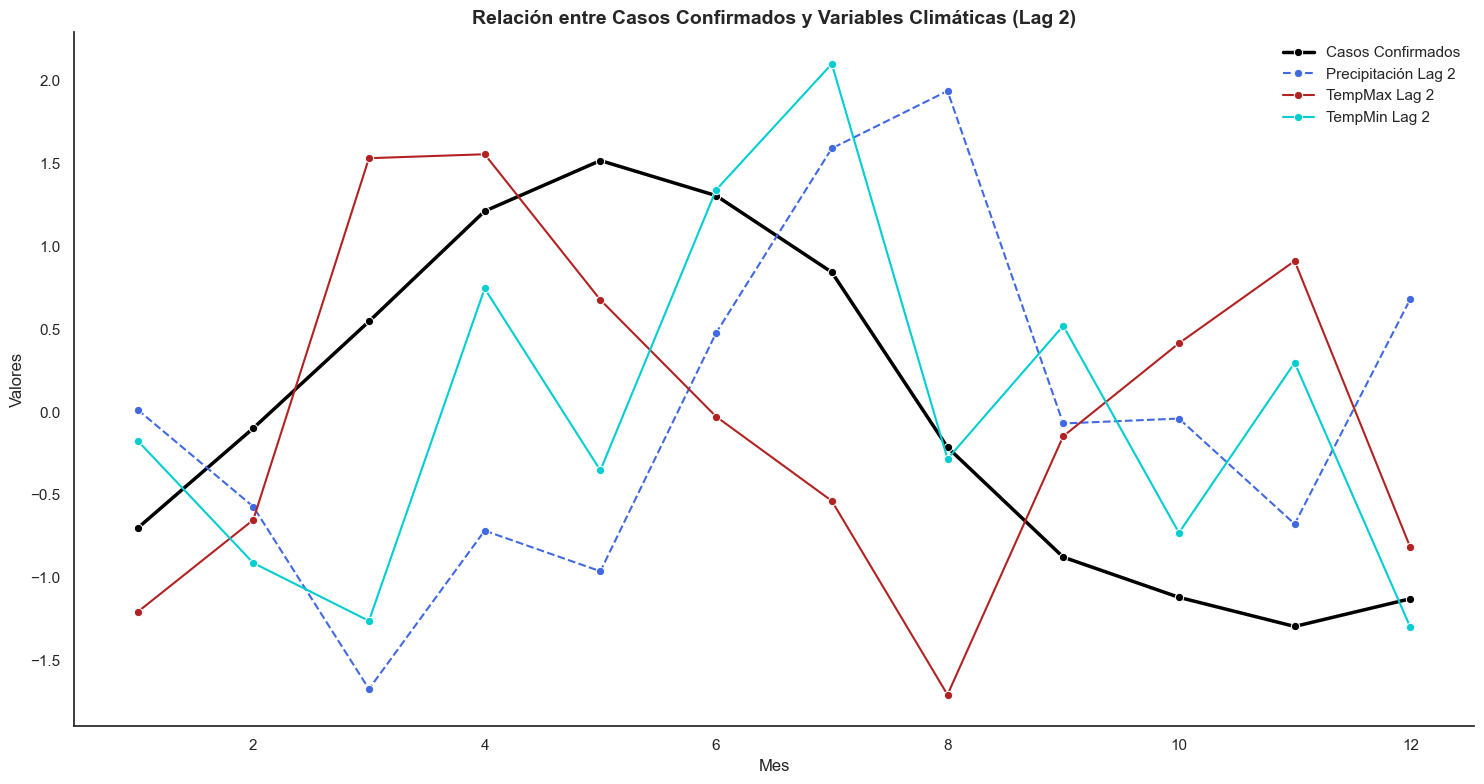

In [61]:
# Set a clean style
sns.set_style("white")

plt.figure(figsize=(15, 8))

# 1. Casos Confirmados: Stronger color and thicker line to make it the focus
sns.lineplot(data=df_lag_2, x='Mes', y='CasosConfirmados', 
             marker='o', label='Casos Confirmados', 
             color='black', linewidth=2.5, errorbar=None)

# 2. Precipitacion: Blue color with a dashed/dotted line style
sns.lineplot(data=df_lag_2, x='Mes', y='Precipitacion_Lag2', 
             marker='o', label='Precipitación Lag 2', 
             color='royalblue', linestyle='--', errorbar=None)

# 3. Temp Max: Warm color (red/orange)
sns.lineplot(data=df_lag_2, x='Mes', y='TempMax_Lag2', 
             marker='o', label='TempMax Lag 2', 
             color='firebrick', errorbar=None)

# 4. Temp Min: Cool color (cyan/light blue)
sns.lineplot(data=df_lag_2, x='Mes', y='TempMin_Lag2', 
             marker='o', label='TempMin Lag 2', 
             color='darkturquoise', errorbar=None)

# Final formatting
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Valores', fontsize=12)
plt.title('Relación entre Casos Confirmados y Variables Climáticas (Lag 2)', fontsize=14, fontweight='bold')
plt.legend(frameon=False) # Remove legend border for a cleaner look
sns.despine() # Removes top and right borders as requested previously

plt.tight_layout()
plt.show()

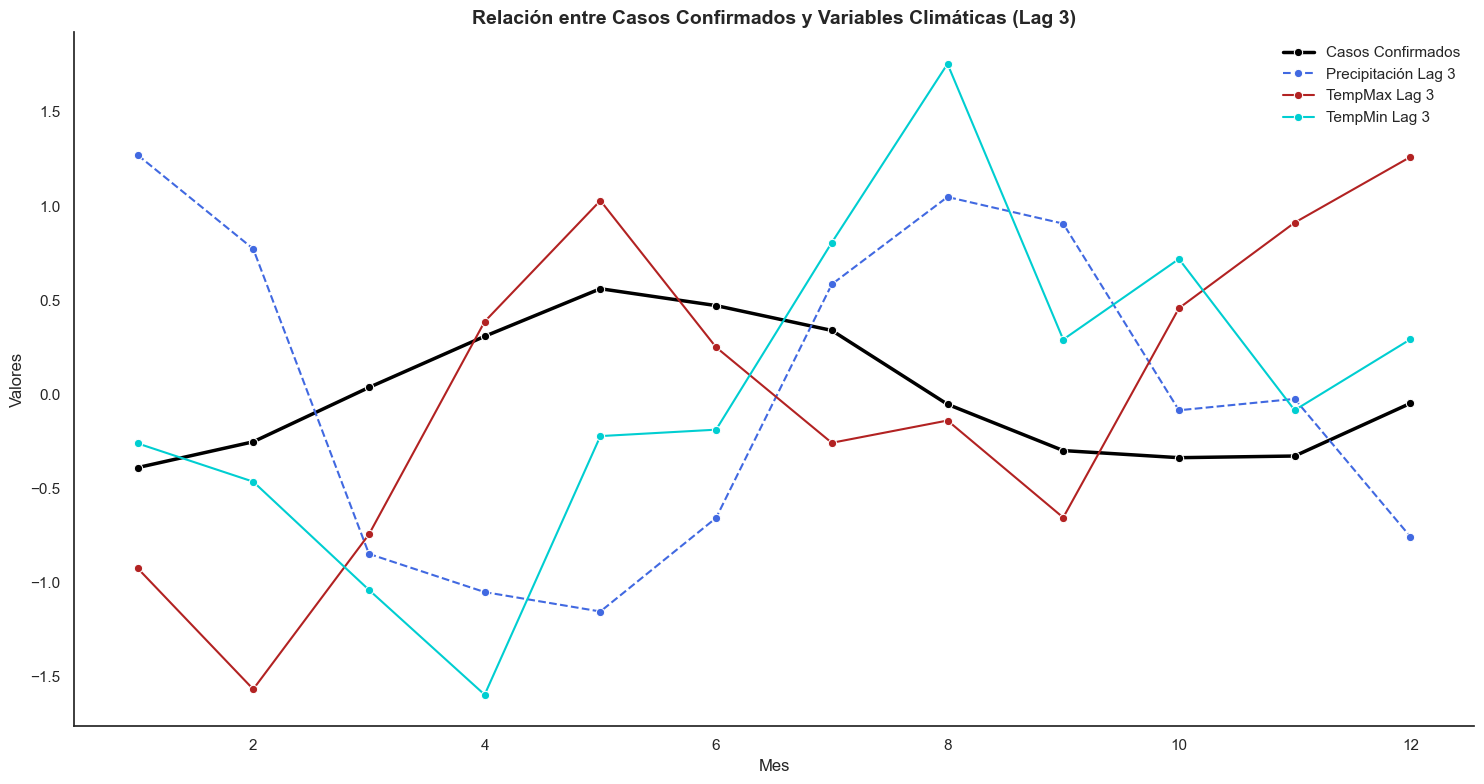

In [53]:
# Set a clean style
sns.set_style("white")

plt.figure(figsize=(15, 8))

# 1. Casos Confirmados: Stronger color and thicker line to make it the focus
sns.lineplot(data=df_lag_2, x='Mes', y='CasosConfirmados', 
             marker='o', label='Casos Confirmados', 
             color='black', linewidth=2.5, errorbar=None)

# 2. Precipitacion: Blue color with a dashed/dotted line style
sns.lineplot(data=df_lag_2, x='Mes', y='Precipitacion_Lag3', 
             marker='o', label='Precipitación Lag 3', 
             color='royalblue', linestyle='--', errorbar=None)

# 3. Temp Max: Warm color (red/orange)
sns.lineplot(data=df_lag_2, x='Mes', y='TempMax_Lag3', 
             marker='o', label='TempMax Lag 3', 
             color='firebrick', errorbar=None)

# 4. Temp Min: Cool color (cyan/light blue)
sns.lineplot(data=df_lag_2, x='Mes', y='TempMin_Lag3', 
             marker='o', label='TempMin Lag 3', 
             color='darkturquoise', errorbar=None)

# Final formatting
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Valores', fontsize=12)
plt.title('Relación entre Casos Confirmados y Variables Climáticas (Lag 3)', fontsize=14, fontweight='bold')
plt.legend(frameon=False) # Remove legend border for a cleaner look
sns.despine() # Removes top and right borders as requested previously

plt.tight_layout()
plt.show()

## 3. Modelado de datos

In [7]:
# librerias de modelado para regresion, lasso, ridge y elastic net
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error, r2_score

In [9]:
df = pd.read_csv('data/dengue_data_v2.csv', sep='|')
df

,CodigoMunicipio,Departamento,Municipio,TipoMunicipio,Longitud,Latitud,Year,Mes,CasosConfirmados,Elevacion,Precipitacion,TempMax,TempMin
0,5001,antioquia,medellin,municipio,-75.581775,6.246631,2007,1,1.0,1609,66.9,25.0,17.0
1,5001,antioquia,medellin,municipio,-75.581775,6.246631,2008,1,128.0,1609,88.6,26.0,15.0
2,5001,antioquia,medellin,municipio,-75.581775,6.246631,2009,1,30.0,1609,137.5,26.0,15.0
3,5001,antioquia,medellin,municipio,-75.581775,6.246631,2010,1,130.0,1609,18.4,29.0,16.0
4,5001,antioquia,medellin,municipio,-75.581775,6.246631,2011,1,126.0,1609,110.9,27.0,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
177931,99773,vichada,cumaribo,municipio,-69.795533,4.446352,2020,12,5.0,134,77.7,33.0,23.0
177932,99773,vichada,cumaribo,municipio,-69.795533,4.446352,2021,12,1.0,134,75.1,33.0,23.0
177933,99773,vichada,cumaribo,municipio,-69.795533,4.446352,2022,12,7.0,134,77.0,32.0,22.0
177934,99773,vichada,cumaribo,municipio,-69.795533,4.446352,2023,12,8.0,134,79.6,33.0,23.0


In [ ]:
# df donde se descartan los identificadores de departamento y municipio y se opera solo con latitud y longitud
df_coords = df.drop(columns=['Departamento', 'Municipio', 'TipoMunicipio'])

df_coords

,Longitud,Latitud,Year,Mes,CasosConfirmados,Elevacion,Precipitacion,TempMax,TempMin,Precipitacion_Lag1,TempMax_Lag1,TempMin_Lag1,Precipitacion_Lag2,TempMax_Lag2,TempMin_Lag2,Precipitacion_Lag3,TempMax_Lag3,TempMin_Lag3
0,-73.207114,-1.748060,2019,4,0.0,158,389.0,31.0,22.0,328.7,31.0,23.0,146.4,31.0,23.0,199.7,31.0,23.0
1,-73.207114,-1.748060,2019,5,0.0,158,253.1,30.0,23.0,389.0,31.0,22.0,328.7,31.0,23.0,146.4,31.0,23.0
2,-73.207114,-1.748060,2019,6,0.0,158,272.1,30.0,22.0,253.1,30.0,23.0,389.0,31.0,22.0,328.7,31.0,23.0
3,-73.207114,-1.748060,2019,7,0.0,158,237.7,29.0,21.0,272.1,30.0,22.0,253.1,30.0,23.0,389.0,31.0,22.0
4,-73.207114,-1.748060,2019,8,0.0,158,141.5,31.0,21.0,237.7,29.0,21.0,272.1,30.0,22.0,253.1,30.0,23.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174622,-70.859499,5.136393,2024,8,0.0,116,255.6,31.0,22.0,325.7,30.0,23.0,431.9,29.0,22.0,340.8,31.0,24.0
174623,-70.859499,5.136393,2024,9,3.0,116,211.5,32.0,23.0,255.6,31.0,22.0,325.7,30.0,23.0,431.9,29.0,22.0
174624,-70.859499,5.136393,2024,10,2.0,116,238.2,32.0,23.0,211.5,32.0,23.0,255.6,31.0,22.0,325.7,30.0,23.0
174625,-70.859499,5.136393,2024,11,0.0,116,149.6,32.0,23.0,238.2,32.0,23.0,211.5,32.0,23.0,255.6,31.0,22.0


In [8]:
# df donde se descartan coordenadas y se opera solo con departamento y municipio codificados como variables dummy
df_cat = df.drop(columns=['Longitud', 'Latitud'])
df_cat['Year'] = df_cat['Year'].astype(str)
df_cat['Mes'] = df_cat['Mes'].astype(str)
# cargar encoders para departamento, municipio y tipo municipio
df_cat = pd.get_dummies(df_cat, columns=['Departamento', 'Municipio', 'TipoMunicipio','Year', 'Mes'], drop_first=True, dtype=int)
df_cat



CasosConfirmados  Elevacion  Precipitacion  TempMax  TempMin  \
0                    0.0        158          389.0     31.0     22.0   
1                    0.0        158          253.1     30.0     23.0   
2                    0.0        158          272.1     30.0     22.0   
3                    0.0        158          237.7     29.0     21.0   
4                    0.0        158          141.5     31.0     21.0   
...                  ...        ...            ...      ...      ...   
174622               0.0        116          255.6     31.0     22.0   
174623               3.0        116          211.5     32.0     23.0   
174624               2.0        116          238.2     32.0     23.0   
174625               0.0        116          149.6     32.0     23.0   
174626               0.0        116           38.5     33.0     23.0   

        Precipitacion_Lag1  Precipitacion_Lag2  Precipitacion_Lag3  \
0                    328.7               146.4               199.7   
1                    389.0               328.7               146.4   
2                    253.1               389.0               328.7   
3                    272.1               253.1               389.0   
4                    237.7               272.1               253.1   
...                    ...                 ...                 ...   
174622               325.7               431.9               340.8   
174623               255.6               325.7               431.9   
174624               211.5               255.6               325.7   
174625               238.2               211.5               255.6   
174626               149.6               238.2               211.5   

        TempMax_Lag1  TempMax_Lag2  TempMax_Lag3  TempMin_Lag1  TempMin_Lag2  \
0               31.0          31.0          31.0          23.0          23.0   
1               31.0          31.0          31.0          22.0          23.0   
2               30.0          31.0          31.0          23.0          22.0   
3               30.0          30.0          31.0          22.0          23.0   
4               29.0          30.0          30.0          21.0          22.0   
...              ...           ...           ...           ...           ...   
174622          30.0          29.0          31.0          23.0          22.0   
174623          31.0          30.0          29.0          22.0          23.0   
174624          32.0          31.0          30.0          23.0          22.0   
174625          32.0          32.0          31.0          23.0          23.0   
174626          32.0          32.0          32.0          23.0          23.0   

        TempMin_Lag3  Departamento_antioquia  Departamento_arauca  \
0               23.0                       0                    0   
1               23.0                       0                    0   
2               23.0                       0                    0   
3               22.0                       0                    0   
4               23.0                       0                    0   
...              ...                     ...                  ...   
174622          24.0                       0                    0   
174623          22.0                       0                    0   
174624          23.0                       0                    0   
174625          22.0                       0                    0   
174626          23.0                       0                    0   

        Departamento_archipielago de san andres, providencia y santa catalina  \
0                                                       0                       
1                                                       0                       
2                                                       0                       
3                                                       0                       
4                                                       0                       
...                       